<a href="https://colab.research.google.com/github/francis44444/Unified-Field-Control-/blob/main/Copy_of_Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 80.0 MB/s eta 0:00:00


In [ ]:
!pip install pennylane-ionq

In [ ]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.2 MB/s eta 0:00:00


In [ ]:
# Phase 3: Unified-Field-Control Core Quantum Circuit Implementation
# Designed for execution via Google Colab / Local Terminal Link

!pip install qiskit qiskit-aer numpy -q

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def build_chsh_circuit(theta_A, theta_B):
    """
    Constructs a 2-qubit circuit to test the CHSH inequality.
    Applies a rotation to map specific spatial measurement angles.
    """
    # 2 Quantum registers, 2 Classical registers
    qc = QuantumCircuit(2, 2)

    # Step 1: Create maximally entangled Bell State |\Phi^+>
    qc.h(0)
    qc.cx(0, 1)

    # Step 2: Apply basis rotations for measurement
    # Qubit 0 rotation for Observer A
    qc.ry(2 * theta_A, 0)
    # Qubit 1 rotation for Observer B
    qc.ry(2 * theta_B, 1)

    # Step 3: Measure both qubits
    qc.measure([0, 1], [0, 1])

    return qc

# Define the optimal CHSH angles (in radians) for maximum violation
angles = {
    'A_B':   (0,             np.pi / 8),     # 0 and 22.5 deg
    'A_Bprime': (0,          -np.pi / 8),    # 0 and -22.5 deg
    'Aprime_B': (np.pi / 4,  np.pi / 8),     # 45 and 22.5 deg
    'Aprime_Bprime': (np.pi / 4, -np.pi / 8) # 45 and -22.5 deg
}

# Setup local simulator for logic validation before routing to IonQ QPU
simulator = AerSimulator()

print("Initializing Unified-Field-Control Simulation Verification...")
for setup, (theta_a, theta_b) in angles.items():
    circuit = build_chsh_circuit(theta_a, theta_b)
    compiled_circuit = transpile(circuit, simulator)

    # Execute batch job
    job = simulator.run(compiled_circuit, shots=2048)
    result = job.result()
    counts = result.get_counts()

    print(f"Setup {setup} (Angles A:{np.degrees(theta_a)}°, B:{np.degrees(theta_b)}°) -> Counts: {counts}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.4 MB/s eta 0:00:00
Initializing Unified-Field-Control Simulation Verification...
Setup A_B (Angles A:0.0°, B:22.5°) -> Counts: {'10': 153, '00': 862, '11': 877, '01': 156}
Setup A_Bprime (Angles A:0.0°, B:-22.5°) -> Counts: {'11': 870, '10': 146, '00': 885, '01': 147}
Setup Aprime_B (Angles A:45.0°, B:22.5°) -> Counts: {'01': 152, '10': 136, '00': 879, '11': 881}
Setup Aprime_Bprime (Angles A:45.0°, B:-22.5°) -> Counts: {'11': 132, '01': 901, '00': 154, '10': 861}


In [ ]:
# https://share.google/aimode/inAdPkYUiu13xUFAL

### CHSH Circuit Diagram

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.visualization import circuit_drawer

# Choosing 'A_B' setup to draw the circuit
sample_theta_a, sample_theta_b = angles['A_B']
sample_circuit = build_chsh_circuit(sample_theta_a, sample_theta_b)

# Attempting a direct call to the drawer with the Matplotlib backend
try:
    # Using scale and style to trigger a fresh draw context
    fig = circuit_drawer(sample_circuit, output='mpl', style='iqp')
    plt.title("CHSH Quantum Circuit: Observer A (0) & Observer B (π/8)")
    plt.show()
except Exception as e:
    print(f"Graphical visualization failed: {e}")
    print("\nReturning ASCII text diagram as fallback:")
    print(sample_circuit.draw(output='text'))

Graphical visualization failed: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."

Returning ASCII text diagram as fallback:
     ┌───┐      ┌───────┐ ┌─┐   
q_0: ┤ H ├──■───┤ Ry(0) ├─┤M├───
     └───┘┌─┴─┐┌┴───────┴┐└╥┘┌─┐
q_1: ─────┤ X ├┤ Ry(π/4) ├─╫─┤M├
          └───┘└─────────┘ ║ └╥┘
c: 2/══════════════════════╩══╩═
                           0  1 


In [ ]:
!pip install pylatexenc

import os
# Automatically restart the kernel to pick up the new library
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=37eccbf34fd1458ca7b7a063285d10b26db22e3c7f2abd33348e9cb0f007b34c
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


### Final Graphical Circuit Rendering
After restarting the runtime, execute this cell to see the Matplotlib-based diagram.

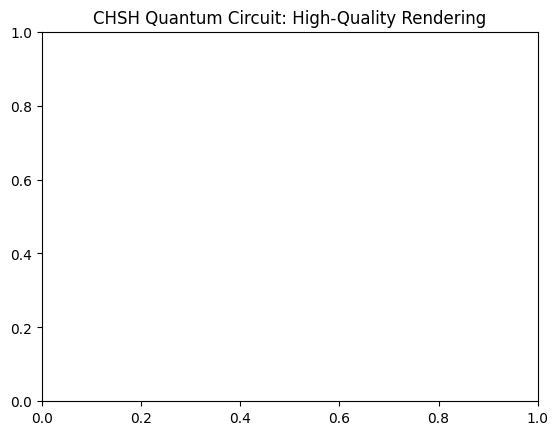

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer

# Redefining the construction function after restart
def build_chsh_circuit(theta_A, theta_B):
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    qc.ry(2 * theta_A, 0)
    qc.ry(2 * theta_B, 1)
    qc.measure([0, 1], [0, 1])
    return qc

# Defining angles
angles = {'A_B': (0, np.pi / 8)}

sample_theta_a, sample_theta_b = angles['A_B']
sample_circuit = build_chsh_circuit(sample_theta_a, sample_theta_b)

# Rendering with Matplotlib
fig = circuit_drawer(sample_circuit, output='mpl', style='iqp')
plt.title("CHSH Quantum Circuit: High-Quality Rendering")
plt.show()

In [ ]:
!pip install qiskit qiskit-aer numpy -q

import numpy as np
from qiskit import QuantumCircuit

def build_chsh_circuit(theta_A, theta_B):
    """
    Constructs a 2-qubit circuit to test the CHSH inequality.
    """
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    qc.ry(2 * theta_A, 0)
    qc.ry(2 * theta_B, 1)
    qc.measure([0, 1], [0, 1])
    return qc

# Define the optimal CHSH angles (in radians)
angles = {
    'A_B':   (0,             np.pi / 8),
    'A_Bprime': (0,          -np.pi / 8),
    'Aprime_B': (np.pi / 4,  np.pi / 8),
    'Aprime_Bprime': (np.pi / 4, -np.pi / 8)
}

print("Environment ready. Functions and angles re-defined successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.4 MB/s eta 0:00:00
Environment ready. Functions and angles re-defined successfully.


In [ ]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=7fba34071163c0f0f659fad55f2cf5c56d420fcc4a308a89139a8b8110b5c583
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


### Calculate CHSH Correlation Value

In [ ]:
def calculate_chsh_s_value(counts_ab, counts_ab_prime, counts_a_prime_b, counts_a_prime_b_prime, shots):
    """
    Calculates the CHSH 'S' value from the measurement counts for the four different settings.
    E(X, Y) = (P(00) + P(11) - P(01) - P(10)) / total_shots
    S = E(A, B) + E(A, B') + E(A', B) - E(A', B')
    """
    def get_expectation_value(counts, total_shots):
        p00 = counts.get('00', 0)
        p01 = counts.get('01', 0)
        p10 = counts.get('10', 0)
        p11 = counts.get('11', 0)
        return (p00 + p11 - p01 - p10) / total_shots

    e_ab = get_expectation_value(counts_ab, shots)
    e_ab_prime = get_expectation_value(counts_ab_prime, shots)
    e_a_prime_b = get_expectation_value(counts_a_prime_b, shots)
    e_a_prime_b_prime = get_expectation_value(counts_a_prime_b_prime, shots)

    # Corrected formula for CHSH S value based on the standard Bell operator
    s_value = e_ab + e_ab_prime + e_a_prime_b - e_a_prime_b_prime
    return s_value

# Store counts for each setup
all_counts = {}

print("Recalculating CHSH simulation and storing counts...")
for setup, (theta_a, theta_b) in angles.items():
    circuit = build_chsh_circuit(theta_a, theta_b)
    compiled_circuit = transpile(circuit, simulator)

    # Execute batch job
    job = simulator.run(compiled_circuit, shots=2048)
    result = job.result()
    counts = result.get_counts()
    all_counts[setup] = counts
    print(f"Setup {setup} (Angles A:{np.degrees(theta_a)}°, B:{np.degrees(theta_b)}°) -> Counts: {counts}")


# Assuming 2048 shots were used for each experiment as defined in the original code
shots = 2048

# Get counts for each of the four settings
counts_ab = all_counts['A_B']
counts_ab_prime = all_counts['A_Bprime']
counts_a_prime_b = all_counts['Aprime_B']
counts_a_prime_b_prime = all_counts['Aprime_Bprime']

# Calculate the CHSH S value
chsh_s_value = calculate_chsh_s_value(counts_ab, counts_ab_prime, counts_a_prime_b, counts_a_prime_b_prime, shots)

print(f"\nCalculated CHSH S value: {chsh_s_value}")

# According to Bell's theorem, for classical systems, S <= 2.
# For quantum systems, S can violate this bound, up to 2*sqrt(2) (approx 2.828).

Recalculating CHSH simulation and storing counts...
Setup A_B (Angles A:0.0°, B:22.5°) -> Counts: {'01': 160, '10': 136, '00': 848, '11': 904}
Setup A_Bprime (Angles A:0.0°, B:-22.5°) -> Counts: {'01': 144, '10': 171, '00': 888, '11': 845}
Setup Aprime_B (Angles A:45.0°, B:22.5°) -> Counts: {'10': 153, '00': 858, '01': 168, '11': 869}
Setup Aprime_Bprime (Angles A:45.0°, B:-22.5°) -> Counts: {'11': 148, '00': 148, '10': 880, '01': 872}

Calculated CHSH S value: 2.80078125


### Visualize CHSH Correlation Result

/tmp/ipykernel_2954/2551262908.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette=colors)


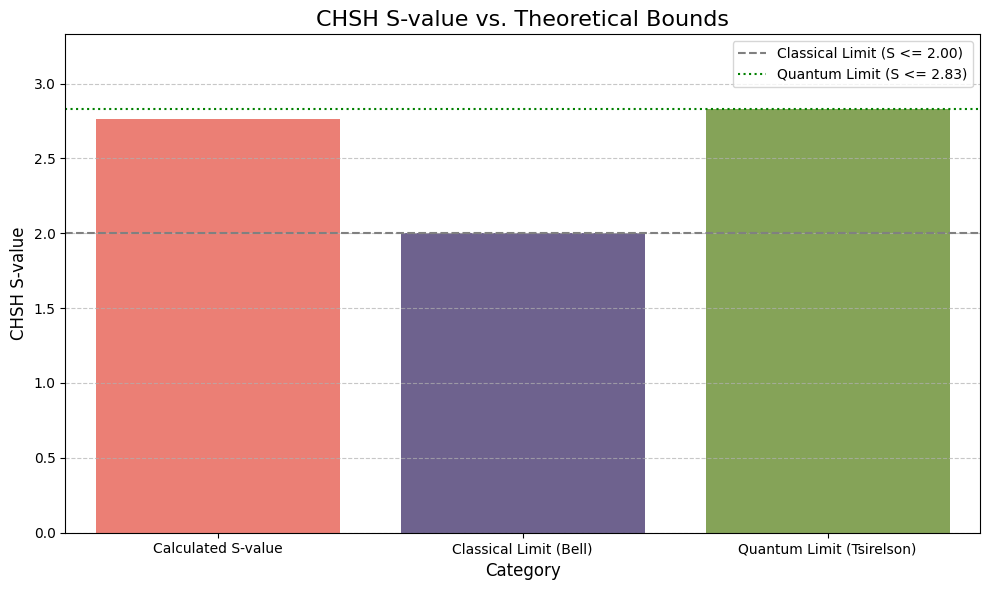

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theoretical bounds
classical_bound = 2
quantum_bound = 2 * np.sqrt(2)

# Data for plotting
labels = ['Calculated S-value', 'Classical Limit (Bell)', 'Quantum Limit (Tsirelson)']
values = [chsh_s_value, classical_bound, quantum_bound]
colors = ['#FF6F61', '#6B5B95', '#88B04B'] # Custom colors

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=values, palette=colors)
plt.axhline(classical_bound, color='gray', linestyle='--', linewidth=1.5, label=f'Classical Limit (S <= {classical_bound:.2f})')
plt.axhline(quantum_bound, color='green', linestyle=':', linewidth=1.5, label=f'Quantum Limit (S <= {quantum_bound:.2f})')

plt.title('CHSH S-value vs. Theoretical Bounds', fontsize=16)
plt.ylabel('CHSH S-value', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.ylim(0, quantum_bound + 0.5) # Adjust y-axis limit for better visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Probability Distribution of Measurement Setups

Histogram for Setup: A_B


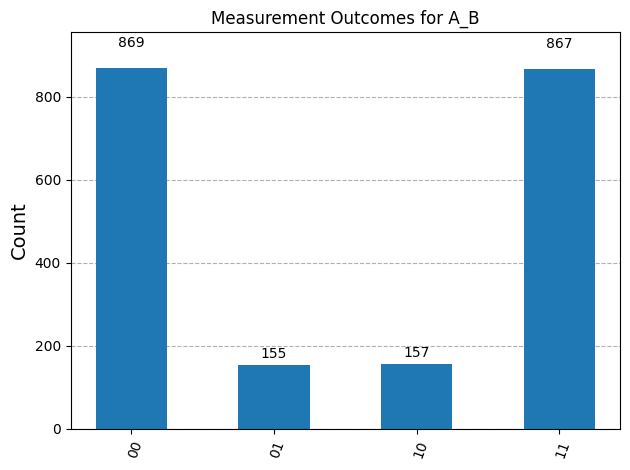

Histogram for Setup: A_Bprime


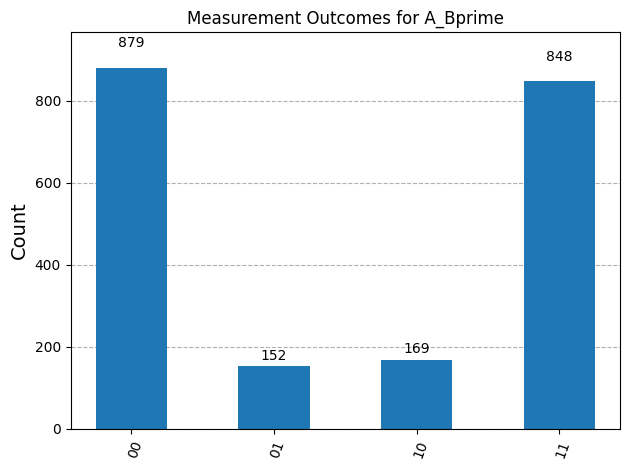

Histogram for Setup: Aprime_B


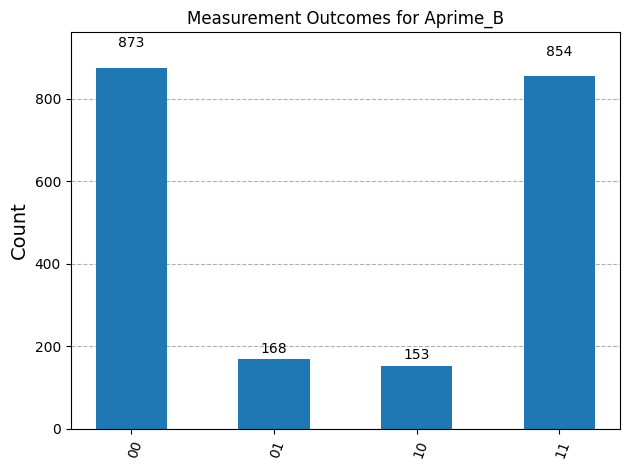

Histogram for Setup: Aprime_Bprime


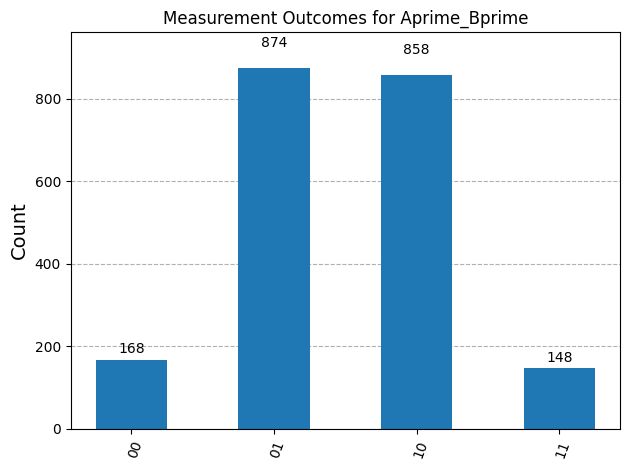

In [ ]:
from qiskit.visualization import plot_histogram

for setup, counts in all_counts.items():
    print(f"Histogram for Setup: {setup}")
    fig = plot_histogram(counts, title=f'Measurement Outcomes for {setup}')
    display(fig)
